# 4. Severity Class Visuals
The goal of this notebook is to generate visuals for a single severity class system (e.g. 1997-type). We assume that the model has already been fitted and heterogeneity values computed prior to running the code in this notebook. This notebook has to be run thrice, once for each of the severity classification systems in the study. See "5_Group Visuals.ipynb" for the visuals that combine results across all three analyses.

In [1]:
library(tidyverse)
library(ggplot2)
library(rstan)
library(Hmisc)
library(forestplot)
theme_set(theme_bw())

── Attaching core tidyverse packages ──────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: StanHeaders

rstan version 2.32.7 (Stan version 2.32.2)

For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Attaching package: ‘rstan’

The follo

In [2]:
inv_logit = plogis
logit = qlogis

save_plot = function(curr_plot, filepath, width, height, units, res, type = "png"){
    if(type == "png"){
        png(filepath, width = width, height = height, units = units, res = res)
    }else if(type == "eps"){
        #Defaults to inches as units
        postscript(filepath, width = width, height = height)
    }else{
        pdf(filepath, width = width, height = height)
    }
    print(curr_plot)
    dev.off()
}

save_plot_all_formats = function(curr_plot, dir_path, filename, width, height, units, res){
    png_path = file.path(dir_path, "png", paste0(filename, ".png"))
    eps_path = file.path(dir_path, "eps", paste0(filename, ".eps"))
    pdf_path = file.path(dir_path, "pdf", paste0(filename, ".pdf"))

    save_plot(curr_plot, png_path, width, height, units, res, type = "png")
    save_plot(curr_plot, eps_path, width, height, units, res, type = "eps")
    save_plot(curr_plot, pdf_path, width, height, units, res, type = "pdf")
}

In [3]:
base_dir = getwd()
io_set = "Main Results"

model_input_dir = file.path(base_dir, "Processed Data", io_set)
model_output_dir = file.path(base_dir, "Model Output", io_set)
het_dir = file.path(base_dir, "Heterogeneity Estimates", io_set)

In [4]:
#Code should be run for each of the severity classifications
sev_class_type = "1997type"
#sev_class_type = "2009type"
#sev_class_type = "hospitalisation"
visuals_output_dir = file.path(base_dir, "Visuals Output", io_set, sev_class_type)



subgroup_forests_dir = file.path(visuals_output_dir, "ScenarioForests")

input_data = file.path(model_input_dir, paste0("data_", sev_class_type, ".rds")) %>% readRDS
model_results = file.path(model_output_dir, paste0("Results_LogisticRegression_mean=0_sd=2_sd_mean=0.5_sdsd=2_", sev_class_type, ".rds")) %>% readRDS
het_results = file.path(het_dir, paste0("I2_Estimates_", sev_class_type, ".rds")) %>% readRDS

In [5]:
save_output = TRUE

# Model Fit Visual
First, we generate a visual showing how the model fits to the data.

In [6]:
#The theta values can be compared to the values in the input outcome_df
outcome_df = input_data$outcome_df

#First, we get our data and compute the 95% binomial confidence intervals
fit_vis_df = outcome_df %>% select(CovidenceID, Scenario, N, Severe) %>%
            cbind(binconf(outcome_df$Severe, outcome_df$N, method = "exact", return.df = TRUE)) %>% 
            mutate(Type = "DATA") %>% select(-c(N, Severe))

#We retrieve the model estimates, which are the values of theta from the model results
theta_est = summary(model_results, pars = "theta")$summary %>% data.frame

fit_vals = theta_est %>% select(mean, X2.5., X97.5.) %>% 
            rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% 
            cbind(fit_vis_df %>% select(CovidenceID, Scenario)) %>% 
            mutate(Type = "MODEL")

fit_vis_df = rbind(fit_vis_df, fit_vals)

#We rename the single study with no author for ease of visaulisation (this was a WHO bulletin)
fit_vis_df = fit_vis_df %>% mutate(CovidenceID = ifelse(CovidenceID == "#9", "#9 - WHO 1987", CovidenceID))
fit_vis_df

                       CovidenceID                 Scenario
X            #661 - Burattini 2016   Americas-Unknown-DENV1
X.1          #661 - Burattini 2016   Americas-Unknown-DENV2
X.2          #661 - Burattini 2016   Americas-Unknown-DENV3
X.3          #661 - Burattini 2016   Americas-Unknown-DENV4
X.4              #4072 - Rosa 2000   Americas-Unknown-DENV1
X.5              #4072 - Rosa 2000   Americas-Unknown-DENV2
X.6             #1503 - Feres 2006   Americas-Unknown-DENV1
X.7             #1503 - Feres 2006   Americas-Unknown-DENV2
X.8             #1503 - Feres 2006   Americas-Unknown-DENV3
X.9          #1776 - Guilarde 2008   Americas-Unknown-DENV3
X.10        #3478 - Ocazionez 2006   Americas-Unknown-DENV1
X.11        #3478 - Ocazionez 2006   Americas-Unknown-DENV4
X.12        #3478 - Ocazionez 2006   Americas-Primary-DENV2
X.13        #3478 - Ocazionez 2006   Americas-Primary-DENV3
X.14        #3478 - Ocazionez 2006 Americas-Secondary-DENV2
X.15        #3478 - Ocazionez 2006 Ameri

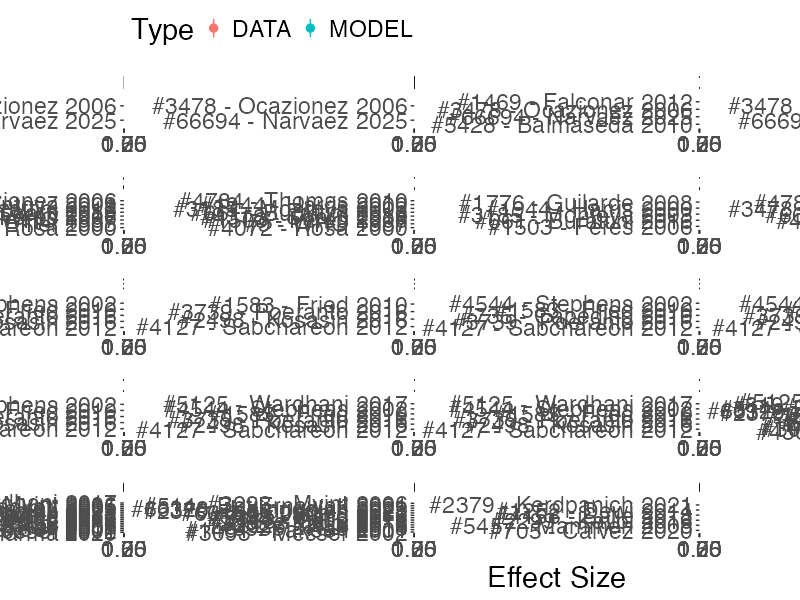

In [7]:
options(repr.plot.width = 25, repr.plot.height = 33)
fit_vis_df %>% 
    ggplot(aes(x = reorder(CovidenceID, PointEst), y = PointEst, ymin = Lower, ymax = Upper, colour = Type)) +
        geom_pointrange(position = position_dodge(width = 0.6)) + 
        coord_flip() + 
        theme(text = element_text(size = 22), legend.position = "top", legend.justification = "left") +
        xlab("Study") + ylab("Effect Size") + ylim(0,1) + 
        facet_wrap(vars(Scenario), scales = "free", ncol = 4)

if(save_output){
    ggsave(file.path(visuals_output_dir, "png", paste0("ModelFitPerStudy", ".png")), width = 25, height = 33, unit = "in", dpi = 800, limitsize = FALSE)
    ggsave(file.path(visuals_output_dir, "eps", paste0("ModelFitPerStudy", ".eps")), width = 25, height = 33, unit = "in", dpi = 800, limitsize = FALSE)
    ggsave(file.path(visuals_output_dir, "pdf", paste0("ModelFitPerStudy", ".pdf")), width = 25, height = 33, unit = "in", dpi = 800, limitsize = FALSE)
}

# Scenario Summary
Here we generate a visual showing the pooled estimate for each scenario.

In [8]:
input_data %>% names
ref_region = input_data$ref_region
non_ref_region = ifelse(ref_region == "Asia", "Americas", "Asia")
ref_serotype_exposure = input_data$ref_serotype_exposure
ref_scenario = input_data$ref_scenario


#Name of what cases are considered severe
severe_name = "Severe"
if(sev_class_type == "1997type"){
    severe_name = "DHF/DSS"
}else if(sev_class_type == "2009type"){
    severe_name = "SD"
}else{
    severe_name = "Hospitalised"
}


In [9]:
non_ref_seroprior = input_data$char_mat_guide %>% filter(CharMatIndex >0) %>% pull(SeroPriorExp) %>% as.character
scenario_labels = c(ref_scenario, 
                    paste0(ref_region, "-", non_ref_seroprior),
                    paste0(non_ref_region, "-", c(ref_serotype_exposure, non_ref_seroprior))
                   )

In [10]:
#Get the scenario estimates, which are given as p from the model
p_estimates = summary(model_results, pars = "p")$summary %>% data.frame
p_estimates = p_estimates %>% select(mean, X2.5., X97.5.) %>% 
    rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% mutate(Scenario = scenario_labels)

scenario_df = input_data$scenario_df %>% left_join(het_results %>% select(Scenario, I2_est), by = "Scenario")
scenario_vis_df = scenario_df %>% left_join(p_estimates, by = "Scenario") %>% 
                    filter(!is.na(CharMatIndex)) %>% 
                    mutate(DispVal = sprintf("%.2f%% [%.2f to %.2f%%]", 100*PointEst, 100*Lower, 100*Upper)) %>%
                    mutate(DispHet = ifelse(is.na(I2_est), "-", sprintf("%.2f%%", I2_est * 100))) %>% 
                    mutate(Pooled = ifelse(Inclusion == "Included", "Pooled", "Not Pooled"))
                    
scenario_vis_df  

      SeroPriorExp   Region                 Scenario NumStudies
1    Unknown-DENV1 Americas   Americas-Unknown-DENV1          8
2    Unknown-DENV2 Americas   Americas-Unknown-DENV2          8
3    Unknown-DENV3 Americas   Americas-Unknown-DENV3          5
4    Unknown-DENV4 Americas   Americas-Unknown-DENV4          5
5    Primary-DENV1 Americas   Americas-Primary-DENV1          1
6    Primary-DENV2 Americas   Americas-Primary-DENV2          2
7    Primary-DENV3 Americas   Americas-Primary-DENV3          2
8  Secondary-DENV1 Americas Americas-Secondary-DENV1          1
9  Secondary-DENV2 Americas Americas-Secondary-DENV2          4
10 Secondary-DENV3 Americas Americas-Secondary-DENV3          2
11 Secondary-DENV4 Americas Americas-Secondary-DENV4          1
12   Unknown-DENV1     Asia       Asia-Unknown-DENV1         15
13   Unknown-DENV2     Asia       Asia-Unknown-DENV2         17
14   Unknown-DENV3     Asia       Asia-Unknown-DENV3         13
15   Unknown-DENV4     Asia       Asia-U

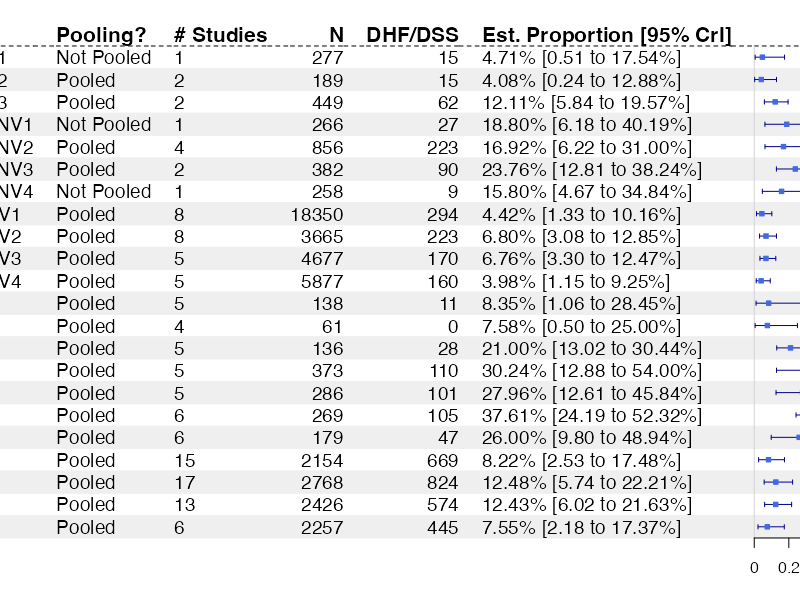

In [11]:
#Generate a forest plot specifically for this severity class
options(repr.plot.width = 15, repr.plot.height = 13)
scenario_plot = scenario_vis_df %>% arrange(Scenario) %>%
    forestplot(labeltext = c(Scenario, Pooled, NumStudies, N, Severe, DispVal, DispHet),
                mean = PointEst, lower = Lower, upper = Upper,
                xticks = seq(0, 1, by = 0.2), ci.vertices = TRUE, boxsize = 0.2,
                align = c("l", "l", "l", "r", "r"), graphwidth = unit(1.8, "in")
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1))) |>
    fp_add_header(
                    Scenario = "Scenario", 
                    Pooled = "Pooling?",
                    NumStudies = "# Studies",
                    N = "N", 
                    Severe = severe_name, 
                    DispVal = "Est. Proportion [95% CrI]",
                    DispHet = expression(I^{2})
    ) |> fp_decorate_graph(graph.pos = 7) |> fp_set_zebra_style("#EFEFEF")

if(save_output){
    #save_plot(scenario_plot, file.path(visuals_output_dir, paste0("SubgroupForest_",  sev_class_type, ".png")), 15, 13, "in", 600)
    save_plot_all_formats(scenario_plot, visuals_output_dir, paste0("SubgroupForest_",  sev_class_type), 15, 13, "in", 600)
}
scenario_plot

# Odds Ratios versus Reference
Here we generate a visual of the odds ratios for each effect versus the reference class.

In [12]:
or_labels = c("Intercept", non_ref_seroprior, non_ref_region)
or_labels

 [1] "Intercept"       "Unknown-DENV1"   "Unknown-DENV2"  
 [4] "Unknown-DENV3"   "Unknown-DENV4"   "Primary-DENV1"  
 [7] "Primary-DENV2"   "Primary-DENV3"   "Secondary-DENV1"
[10] "Secondary-DENV3" "Secondary-DENV4" "Americas"       

In [13]:
process_or_beta = function(par_name){
    beta_or_est  = summary(model_results, pars = c(par_name))$summary %>% data.frame %>%
                mutate(Label = or_labels) %>% select(Label, mean, X2.5., X97.5.) %>% 
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.)
    return(beta_or_est)
}
log_beta_or_est = process_or_beta("log_or_beta") %>% select(-Label) %>% rename(LogPointEst = PointEst, LogLower = Lower, LogUpper = Upper)
beta_or_est = process_or_beta("or_beta")

beta_or_est = cbind(beta_or_est, log_beta_or_est)

In [14]:
#We don't need the intercept
ref_seroexp_label = data.frame(Label = paste0("Versus ", ref_serotype_exposure), PointEst = NA, Lower = NA, Upper  = NA, LogPointEst = NA, LogLower = NA, LogUpper = NA, DispVal = NA, LogDispVal = NA)
ref_region_label = data.frame(Label = paste0("Versus ", ref_region), PointEst = NA, Lower = NA, Upper  = NA, LogPointEst = NA, LogLower = NA, LogUpper = NA, DispVal = NA, LogDispVal = NA)
beta_or_vis_df = beta_or_est %>% filter(Label != "Intercept") %>% 
                    mutate(DispVal = sprintf("%.2f [%.2f to %.2f]", PointEst, Lower, Upper)) %>% 
                    mutate(LogDispVal = sprintf("%.2f [%.2f to %.2f]", LogPointEst, LogLower, LogUpper))

or_seroexp_part = beta_or_vis_df %>% filter(Label != non_ref_region) %>% mutate(Label = paste0("     ", Label))
or_region_part = beta_or_vis_df %>% filter(Label == non_ref_region)%>% mutate(Label = paste0("     ", Label))

beta_or_vis_df = rbind(ref_seroexp_label, or_seroexp_part, ref_region_label, or_region_part)

#Add significance labels
beta_or_vis_df = beta_or_vis_df %>% mutate(DispVal = ifelse(((Lower > 1) | (Upper < 1)), paste0(DispVal, "*"), DispVal),
                                          LogDispVal = ifelse(((LogLower > 0) | (LogUpper < 0)), paste0(LogDispVal, "*"), LogDispVal))

In [15]:
beta_or_vis_df

                             Label  PointEst      Lower
1           Versus Secondary-DENV2        NA         NA
or_beta[2]           Unknown-DENV1 0.2654357 0.05925284
or_beta[3]           Unknown-DENV2 0.4235938 0.12714401
or_beta[4]           Unknown-DENV3 0.4224410 0.13154946
or_beta[5]           Unknown-DENV4 0.2430965 0.04989031
or_beta[6]           Primary-DENV1 0.2859482 0.02798589
or_beta[7]           Primary-DENV2 0.2475692 0.01326610
or_beta[8]           Primary-DENV3 0.7974270 0.27592376
or_beta[9]         Secondary-DENV1 1.3865550 0.32891868
or_beta[10]        Secondary-DENV3 1.8290737 0.62575251
or_beta[11]        Secondary-DENV4 1.1038603 0.24986023
11                     Versus Asia        NA         NA
or_beta[12]               Americas 0.5312091 0.27021273
                Upper LogPointEst   LogLower    LogUpper
1                  NA          NA         NA          NA
or_beta[2]  0.7674594  -1.5371698 -2.8259415 -0.26466964
or_beta[3]  1.1047313  -1.0144339 -2.0624349 

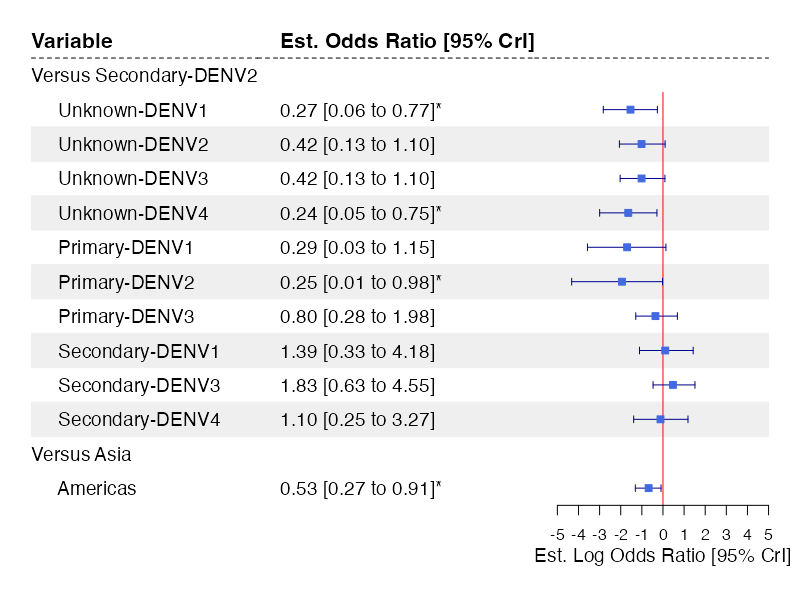

In [16]:
options(repr.plot.width = 10, repr.plot.height = 10)
or_versus_ref_plot = beta_or_vis_df %>%forestplot(labeltext = c(Label, DispVal), zero = 0,
                mean = LogPointEst, lower = LogLower, upper = LogUpper,
                xticks = seq(-5, 5, by = 1), ci.vertices = TRUE, boxsize = 0.2,
                align = c("l", "l"), graphwidth = unit(2.2, "in"), xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue", zero = "red",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1), xlab = gpar(cex = 1.2))) |>
    fp_add_header(
                    Label = "Variable", 
                    DispVal = "Est. Odds Ratio [95% CrI]"
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]"
    ) |> fp_set_zebra_style("#EFEFEF")

if(save_output){
    #save_plot(or_versus_ref_plot, file.path(visuals_output_dir, paste0("ORvsRef_",  sev_class_type, ".png")), 10, 10, "in", 600)
    save_plot_all_formats(or_versus_ref_plot, visuals_output_dir, paste0("ORvsRef_",  sev_class_type), 10, 10, "in", 600)
}
or_versus_ref_plot

# Odds Ratio Pairwise Comparison (Serotype - Prior Exposure)
Here, we generate a visual showing pairs of serotype-prior exposure effects and the odds ratio for severity between them (including the reference class and whether the difference was significant or not).

In [17]:
char_mat_guide = input_data$char_mat_guide
char_mat_guide

      SeroPriorExp CharMatIndex
1    Unknown-DENV1            1
2    Unknown-DENV2            2
3    Unknown-DENV3            3
4    Unknown-DENV4            4
5    Primary-DENV1            5
6    Primary-DENV2            6
7    Primary-DENV3            7
8  Secondary-DENV1            8
9  Secondary-DENV2           -1
10 Secondary-DENV3            9
11 Secondary-DENV4           10

In [18]:
#We create a visual to show pairwise odds ratios (these would be in the sero_prior_or_ratios matrix)
sero_prior_mat = summary(model_results, pars = "sero_prior_or_ratios")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>%
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>%
                mutate(Name = rownames(.)) %>%
                separate(Name, sep = "\\[|,|\\]", into = c(NA, "ROW", "COL", NA)) %>% 
                mutate(ROW = as.numeric(ROW), COL = as.numeric(COL)) %>%
                filter(COL > ROW) %>% 
                left_join(char_mat_guide, by = c("ROW" = "CharMatIndex")) %>% #Join the indices based on the input char_mat_guide
                rename(RowScenario = SeroPriorExp) %>% 
                left_join(char_mat_guide, by = c("COL" = "CharMatIndex")) %>%
                rename(ColScenario = SeroPriorExp) %>% 
                select(-c(ROW, COL))

log_sero_prior_mat  = summary(model_results, pars = "log_sero_prior_or_ratios")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>%
                rename(LogPointEst = mean, LogLower = X2.5., LogUpper = X97.5.) %>% mutate(Name = rownames(.)) %>%
                separate(Name, sep = "\\[|,|\\]", into = c(NA, "ROW", "COL", NA)) %>% 
                mutate(ROW = as.numeric(ROW), COL = as.numeric(COL)) %>%
                filter(COL > ROW) %>%
                select(-c(ROW, COL))
sero_prior_mat = cbind(sero_prior_mat, log_sero_prior_mat)

In [19]:
versus_ref_portion = beta_or_est %>% filter(!Label %in% c("Intercept", non_ref_region)) %>%
                        mutate(ColScenario = ref_serotype_exposure) %>% rename(RowScenario = Label)
#We add in the part of the matrix versus the reference class (the reference is the denominator of the OR)

sero_prior_mat_vis = sero_prior_mat %>% rbind(versus_ref_portion) %>% 
                    mutate(Significance = ifelse(((Lower > 1) | (Upper < 1)),"Significant", "Not Significant")) %>% #Check for significant OR   
                    arrange(desc(Significance), desc(PointEst)) %>% 
                    mutate(DispVal = sprintf("%.2f [%.2f to %.2f]", PointEst, Lower, Upper),
                          LogDispVal = sprintf("%.2f [%.2f to %.2f]", LogPointEst, LogLower, LogUpper))
sero_prior_mat_vis

                                PointEst       Lower      Upper
log_sero_prior_or_ratios[7,9]  0.4707733 0.200935552  0.9311441
log_sero_prior_or_ratios[1,7]  0.3614189 0.092967927  0.9080098
log_sero_prior_or_ratios[4,7]  0.3296651 0.080481292  0.8919696
log_sero_prior_or_ratios[4,10] 0.2918115 0.047370296  0.9691525
or_beta[2]                     0.2654357 0.059252843  0.7674594
log_sero_prior_or_ratios[2,9]  0.2515391 0.090757997  0.5636993
log_sero_prior_or_ratios[1,8]  0.2509334 0.043896785  0.7848133
log_sero_prior_or_ratios[3,9]  0.2500863 0.095153970  0.5451629
or_beta[7]                     0.2475692 0.013266096  0.9803883
or_beta[5]                     0.2430965 0.049890308  0.7519920
log_sero_prior_or_ratios[4,8]  0.2310731 0.037927876  0.7576272
log_sero_prior_or_ratios[5,9]  0.1777844 0.016985296  0.7168097
log_sero_prior_or_ratios[1,9]  0.1594448 0.039635369  0.4194492
log_sero_prior_or_ratios[6,9]  0.1525668 0.008319097  0.5690905
log_sero_prior_or_ratios[4,9]  0.1445604

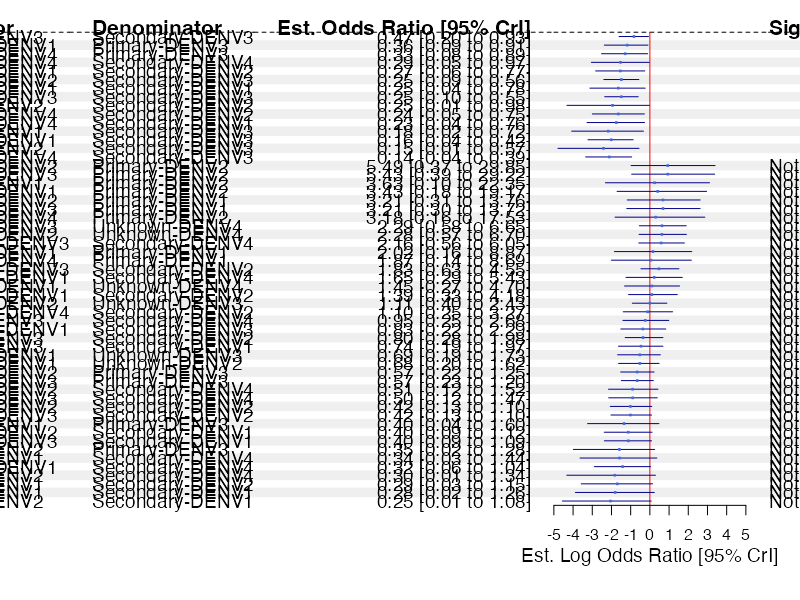

In [20]:
options(repr.plot.width = 13, repr.plot.height = 18)

axis_lim = 5
sero_prior_comp_plot = sero_prior_mat_vis %>%
                forestplot(labeltext = c(RowScenario, ColScenario, DispVal, Significance), zero = 0,
                mean = LogPointEst, lower = LogLower, upper = LogUpper, clip = c(-axis_lim, axis_lim),
                xticks = seq(-axis_lim, axis_lim, by = as.integer(axis_lim/5)), boxsize = 0.2,
                align = c("l", "l", "r", "r"), graphwidth = unit(2, "in"), ci.vertices.height = 0.2, xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), zero = "red", summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1), xlab = gpar(cex = 1.2))) |>
    fp_add_header(
                    RowScenario = "Numerator", 
                    ColScenario = "Denominator", 
                    DispVal = "Est. Odds Ratio [95% CrI]",
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]",
                    Significance = "Significance"
    ) |> fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 4)
if(save_output){
    #save_plot(sero_prior_comp_plot, file.path(visuals_output_dir, paste0("SeroPriorComp_",  sev_class_type, ".png")), 15, 18, "in", 600)
    save_plot_all_formats(sero_prior_comp_plot, visuals_output_dir, paste0("SeroPriorComp_",  sev_class_type), 15, 18, "in", 600)
}
sero_prior_comp_plot

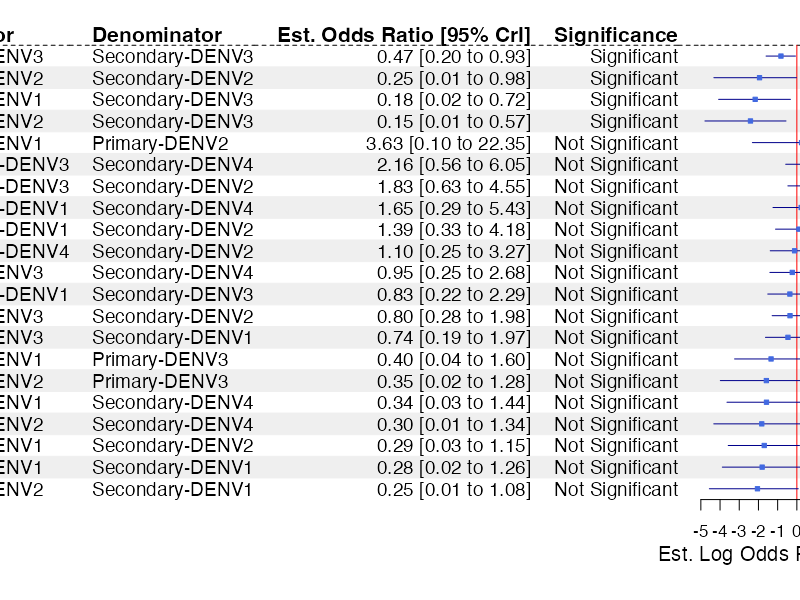

In [21]:
#Same plot as abive but without the unknowns
options(repr.plot.width = 13, repr.plot.height = 12)
axis_lim = 5
sero_prior_comp_plot_known = sero_prior_mat_vis %>% filter(!(str_detect(RowScenario, "Unknown") | str_detect(ColScenario, "Unknown"))) %>%
                forestplot(labeltext = c(RowScenario, ColScenario, DispVal, Significance), zero = 0, 
                clip = c(-axis_lim, axis_lim), 
                mean = LogPointEst, lower = LogLower, upper = LogUpper,
                xticks = seq(-axis_lim, axis_lim, by = as.integer(axis_lim/5)), 
                ci.vertices = FALSE, boxsize = 0.2, ci.vertices.height = 0.2, 
                align = c("l", "l", "r", "r"), graphwidth = unit(2, "in"), xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), zero = "red", summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1.1), xlab = gpar(cex = 1.3))) |>
    fp_add_header(
                    RowScenario = "Numerator", 
                    ColScenario = "Denominator", 
                    DispVal = "Est. Odds Ratio [95% CrI]",
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]",
                    Significance = "Significance"
    ) |> fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 5)
if(save_output){
    #save_plot(sero_prior_comp_plot_known, file.path(visuals_output_dir, paste0("SeroPriorComp_Known_",  sev_class_type, ".png")), 13, 12, "in", 600)
    save_plot_all_formats(sero_prior_comp_plot_known, visuals_output_dir, paste0("SeroPriorComp_Known_",  sev_class_type), 13, 12, "in", 600)
}
sero_prior_comp_plot_known

# Scenario Forests
In this section, we make individual forest plots for each of the scenarios where we pool data.

In [22]:
theta_df = summary(model_results, pars = "theta")$summary %>% data.frame %>% 
                select(mean, X2.5., X97.5.) %>% rename(PointEst = mean, Lower = X2.5., Upper = X97.5.)

outcome_ests = outcome_df %>% cbind(theta_df) %>% 
                mutate(DispVal = sprintf("%.2f%% [%.2f to %.2f%%]", 100*PointEst, 100*Lower, 100*Upper))

outcome_ests

            ID              CovidenceID   Region Serotype
theta[1]  0021    #661 - Burattini 2016 Americas    DENV1
theta[2]  0021    #661 - Burattini 2016 Americas    DENV2
theta[3]  0021    #661 - Burattini 2016 Americas    DENV3
theta[4]  0021    #661 - Burattini 2016 Americas    DENV4
theta[5]  0291        #4072 - Rosa 2000 Americas    DENV1
theta[6]  0291        #4072 - Rosa 2000 Americas    DENV2
theta[7]  0186       #1503 - Feres 2006 Americas    DENV1
theta[8]  0186       #1503 - Feres 2006 Americas    DENV2
theta[9]  0186       #1503 - Feres 2006 Americas    DENV3
theta[10] 0097    #1776 - Guilarde 2008 Americas    DENV3
theta[11] 0257   #3478 - Ocazionez 2006 Americas    DENV1
theta[12] 0257   #3478 - Ocazionez 2006 Americas    DENV4
theta[13] 0257   #3478 - Ocazionez 2006 Americas    DENV2
theta[14] 0257   #3478 - Ocazionez 2006 Americas    DENV3
theta[15] 0257   #3478 - Ocazionez 2006 Americas    DENV2
theta[16] 0257   #3478 - Ocazionez 2006 Americas    DENV3
theta[17] 0250

In [23]:
inc_scenarios = scenario_vis_df %>% filter(Inclusion != "Excluded")

for(i in 1:nrow(inc_scenarios)){
    curr_row = inc_scenarios[i, ]
    curr_scen = curr_row$Scenario
    curr_scen_outcomes = outcome_ests %>% filter(Scenario == curr_scen)
    options(repr.plot.width = 13, repr.plot.height = nrow(curr_scen_outcomes))
    curr_scenario_plot = curr_scen_outcomes %>%
                    forestplot(labeltext = c(CovidenceID, Scenario, N, Severe, DispVal),
                    clip = c(-axis_lim, axis_lim), 
                    mean = PointEst, lower = Lower, upper = Upper,
                    xticks = seq(0, 1, by = 0.2), 
                    ci.vertices = FALSE, boxsize = 0.2, ci.vertices.height = 0.2, 
                    align = c("l", "l", "r", "r", "r"), graphwidth = unit(2, "in")
                  ) |>
        fp_add_lines(h_2 = gpar(lty = 2)) |>
        fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                    txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1))) |>
        fp_add_header(
                        CovidenceID = "CovidenceID", 
                        Scenario = "Scenario", 
                        N = "N",
                        Severe = "Severe",
                        DispVal = "Est. Proportion [95% CrI]"
        ) |>  
        fp_append_row(
                mean = curr_row %>% pull(PointEst),
                lower = curr_row %>% pull(Lower),
                upper = curr_row %>% pull(Upper),
                CovidenceID = "Summary",
                DispVal = curr_row %>% pull(DispVal),
                is.summary = TRUE
        ) |>
        fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 6)
    
    if(save_output){
        #save_plot(curr_scenario_plot, file.path(subgroup_forests_dir, paste0("Forest_", curr_scen, ".png")), 13, nrow(curr_scen_outcomes), "in", 600)
        save_plot_all_formats(curr_scenario_plot, subgroup_forests_dir, paste0("Forest_",  curr_scen), 13, nrow(curr_scen_outcomes), "in", 600)
    }
}
